# IMDb Review Text Analysis

This notebook performs text analysis on IMDb reviews to understand:
- Why people like specific movies
- What aspects of movies are appreciated by genre
- Common themes in positive reviews

## Pipeline:
1. Load and merge review data
2. Text preprocessing (cleaning, tokenization, stop words, stemming)
3. Sentiment analysis
4. Filter positive reviews
5. Clustering analysis
6. Visualization (word clouds, t-SNE/UMAP)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## Step 1: Load IMDb Reviews Data

Load the raw review data and examine its structure.

In [2]:
# Load IMDb reviews
reviews_df = pd.read_csv('../data/raw/imdb_reviews.csv')

print(f"Dataset shape: {reviews_df.shape}")
print(f"\nColumn names: {reviews_df.columns.tolist()}")
print(f"\nData types:")
print(reviews_df.dtypes)

Dataset shape: (113538, 4)

Column names: ['movie_id', 'title', 'review', 'rating']

Data types:
movie_id    object
title       object
review      object
rating      object
dtype: object


In [3]:
# Display first few rows
reviews_df.head()

,movie_id,title,review,rating
0,tt0058548,People Need To Lighten Up About This Movie,This is certainly a consensus pick as one of the worst (if not the worst) movies ever made - and...,4
1,tt0058548,Not NEARLY as bad as people make it out to be...AND a lot more fun than it has any right to be!,"I still very much appreciate its spirit, both in terms of no-budget filmmaking and sense of fun....",4
2,tt0058548,Can something this dumb really be harmless?,"Maybe I have a soft spot somewhere in my heart for poorly written, badly conceived, silly 1960s ...",4
3,tt0058548,"Ludicrous, yet charming, Christmas-based nonsense",Santa Claus Conquers the Martians is a low budget kid's movie from the early 60's. It has a repu...,5
4,tt0058548,Harmless Christmas fun.,"I badly want to give this film a 3/10, because it is by today's standards, abysmal. However, you...",5


In [4]:
# Check for missing values
print("Missing values:")
print(reviews_df.isnull().sum())
print(f"\nMissing percentage:")
print((reviews_df.isnull().sum() / len(reviews_df) * 100).round(2))

Missing values:
movie_id    0
title       2
review      0
rating      0
dtype: int64

Missing percentage:
movie_id    0.0
title       0.0
review      0.0
rating      0.0
dtype: float64


In [5]:
# Basic statistics
reviews_df.describe()

,movie_id,title,review,rating
count,113538,113536,113538,113538
unique,146,94491,107584,11
top,tt0111161,Amazing,[No Review],10
freq,9184,346,5611,30737


In [6]:
# Check unique movies
print(f"Number of unique movies: {reviews_df['movie_id'].nunique()}")
print(f"Total reviews: {len(reviews_df)}")
print(f"Average reviews per movie: {len(reviews_df) / reviews_df['movie_id'].nunique():.2f}")

Number of unique movies: 146
Total reviews: 113538
Average reviews per movie: 777.66


In [7]:
# Examine review text lengths
reviews_df['review_length'] = reviews_df['review'].astype(str).apply(len)
reviews_df['word_count'] = reviews_df['review'].astype(str).apply(lambda x: len(x.split()))

print("Review length statistics:")
print(reviews_df[['review_length', 'word_count']].describe())

Review length statistics:
       review_length     word_count
count  113538.000000  113538.000000
mean      815.995887     145.040039
std       891.953557     155.511478
min         6.000000       1.000000
25%       236.000000      43.000000
50%       636.000000     115.000000
75%       980.000000     176.000000
max      9994.000000    1934.000000


In [8]:
# Sample reviews
print("Sample review:")
print("=" * 80)
sample_idx = reviews_df['review_length'].idxmax()  # Show a longer review
print(f"Movie ID: {reviews_df.loc[sample_idx, 'movie_id']}")
if 'rating' in reviews_df.columns:
    print(f"Rating: {reviews_df.loc[sample_idx, 'rating']}")
print(f"Review: {reviews_df.loc[sample_idx, 'review'][:500]}...")

Sample review:
Movie ID: tt7462410
Rating: 7
Review: A bold and ingenious beginning that explored the highly anticipated adaptation of Robert Jordan's 14-book saga. "The Wheel Of Time" drew elements from the first three novels. It was a breathtaking enlivening of Robert's stories but was, understandingly, not as intricate - there's only so much a TV series can extract. To be honest, I have not read any of the books - a point I am slightly ashamed to make. I have to make mention of that because this review is going to read like someone who has excl...


### Summary of Step 1

**Dataset loaded successfully!**

- Total reviews: 113,538
- Unique movies: Need to check
- Columns: `movie_id`, `title`, `review`, `rating`
- Average review length: 816 characters, 145 words
- Review lengths vary widely (6 to 9,994 characters)

## Step 2: Merge with Movie Metadata

Join the reviews with movie metadata to enable genre-based analysis.

In [9]:
# Load movie metadata
movies_df = pd.read_csv('../data/processed/imdb_tmdb_combined.csv')

print(f"Movies dataset shape: {movies_df.shape}")
print(f"\nMovie columns: {movies_df.columns.tolist()}")
movies_df.head()

Movies dataset shape: (30140, 26)

Movie columns: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'genres', 'averageRating', 'numVotes', 'tmdb_id', 'budget', 'revenue', 'tmdb_popularity', 'tmdb_vote_average', 'tmdb_vote_count', 'production_countries', 'production_companies', 'spoken_languages', 'original_language', 'tagline', 'roi', 'profit', 'has_budget_data', 'has_revenue_data']


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,tmdb_id,budget,revenue,tmdb_popularity,tmdb_vote_average,tmdb_vote_count,production_countries,production_companies,spoken_languages,original_language,tagline,roi,profit,has_budget_data,has_revenue_data
0,tt0111161,movie,The Shawshank Redemption,The Shawshank Redemption,0.0,1994.0,NaN,142.0,Drama,9.3,3103987,278.0,25000000.0,2.834147e+07,29.4501,8.712,28979.0,US,Castle Rock Entertainment,en,en,Fear can hold you prisoner. Hope can set you free.,13.365876,3341469.0,True,True
1,tt0468569,movie,The Dark Knight,The Dark Knight,0.0,2008.0,NaN,152.0,"Action,Crime,Drama",9.1,3079053,155.0,185000000.0,1.004558e+09,29.7975,8.523,34497.0,"GB,US","Warner Bros. Pictures,Legendary Pictures,Syncopy,DC","en,zh",en,Welcome to a world without rules.,443.004564,819558444.0,True,True
2,tt1375666,movie,Inception,Inception,0.0,2010.0,NaN,148.0,"Action,Adventure,Sci-Fi",8.8,2734473,27205.0,160000000.0,8.390306e+08,24.5437,8.370,38040.0,"GB,US","Legendary Pictures,Syncopy,Warner Bros. Pictures","en,fr,ja,sw",en,Your mind is the scene of the crime.,424.394144,679030630.0,True,True
3,tt0137523,movie,Fight Club,Fight Club,0.0,1999.0,NaN,139.0,"Crime,Drama,Thriller",8.8,2519445,550.0,63000000.0,1.008538e+08,23.6478,8.437,30842.0,"DE,US","Fox 2000 Pictures,Regency Enterprises,Linson Entertainment,20th Century Fox,Taurus Film",en,en,Mischief. Mayhem. Soap.,60.085322,37853753.0,True,True
4,tt0109830,movie,Forrest Gump,Forrest Gump,0.0,1994.0,NaN,142.0,"Drama,Romance",8.8,2423611,13.0,55000000.0,6.773877e+08,18.6102,8.500,28697.0,US,"Paramount Pictures,The Steve Tisch Company,Wendy Finerman Productions",en,en,The world will never be the same once you've seen it through the eyes of Forrest Gump.,1131.614029,622387716.0,True,True


In [10]:
# Check if movie_id column exists and format
print(f"Columns in movies_df related to ID: {[col for col in movies_df.columns if 'id' in col.lower() or 'const' in col.lower()]}")
print(f"Columns in reviews_df: {reviews_df.columns.tolist()}")

# The movies_df uses 'tconst' while reviews_df uses 'movie_id'
# Check for common movie IDs
common_movies = set(reviews_df['movie_id'].unique()).intersection(set(movies_df['tconst'].unique()))
print(f"\nNumber of movies with reviews: {reviews_df['movie_id'].nunique()}")
print(f"Number of movies in metadata: {movies_df['tconst'].nunique()}")
print(f"Number of common movies: {len(common_movies)}")

Columns in movies_df related to ID: ['tconst', 'tmdb_id']
Columns in reviews_df: ['movie_id', 'title', 'review', 'rating', 'review_length', 'word_count']

Number of movies with reviews: 146
Number of movies in metadata: 30140
Number of common movies: 125


In [11]:
# Merge reviews with movie metadata (using tconst as the join key)
merged_df = reviews_df.merge(movies_df, left_on='movie_id', right_on='tconst', how='inner')

print(f"Merged dataset shape: {merged_df.shape}")
print(f"\nColumns in merged dataset:")
print(merged_df.columns.tolist())
print(f"\nReviews matched with metadata: {len(merged_df)} / {len(reviews_df)} ({len(merged_df)/len(reviews_df)*100:.2f}%)")

Merged dataset shape: (75256, 32)

Columns in merged dataset:
['movie_id', 'title', 'review', 'rating', 'review_length', 'word_count', 'tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'genres', 'averageRating', 'numVotes', 'tmdb_id', 'budget', 'revenue', 'tmdb_popularity', 'tmdb_vote_average', 'tmdb_vote_count', 'production_countries', 'production_companies', 'spoken_languages', 'original_language', 'tagline', 'roi', 'profit', 'has_budget_data', 'has_revenue_data']

Reviews matched with metadata: 75256 / 113538 (66.28%)


In [12]:
# Display sample of merged data
merged_df.head()

,movie_id,title,review,rating,review_length,word_count,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,tmdb_id,budget,revenue,tmdb_popularity,tmdb_vote_average,tmdb_vote_count,production_countries,production_companies,spoken_languages,original_language,tagline,roi,profit,has_budget_data,has_revenue_data
0,tt0058548,People Need To Lighten Up About This Movie,This is certainly a consensus pick as one of the worst (if not the worst) movies ever made - and...,4,1281,243,tt0058548,movie,Santa Claus Conquers the Martians,Santa Claus Conquers the Martians,0.0,1964.0,NaN,81.0,"Adventure,Comedy,Family",2.8,13086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
1,tt0058548,Not NEARLY as bad as people make it out to be...AND a lot more fun than it has any right to be!,"I still very much appreciate its spirit, both in terms of no-budget filmmaking and sense of fun....",4,832,131,tt0058548,movie,Santa Claus Conquers the Martians,Santa Claus Conquers the Martians,0.0,1964.0,NaN,81.0,"Adventure,Comedy,Family",2.8,13086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2,tt0058548,Can something this dumb really be harmless?,"Maybe I have a soft spot somewhere in my heart for poorly written, badly conceived, silly 1960s ...",4,2063,367,tt0058548,movie,Santa Claus Conquers the Martians,Santa Claus Conquers the Martians,0.0,1964.0,NaN,81.0,"Adventure,Comedy,Family",2.8,13086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
3,tt0058548,"Ludicrous, yet charming, Christmas-based nonsense",Santa Claus Conquers the Martians is a low budget kid's movie from the early 60's. It has a repu...,5,1340,236,tt0058548,movie,Santa Claus Conquers the Martians,Santa Claus Conquers the Martians,0.0,1964.0,NaN,81.0,"Adventure,Comedy,Family",2.8,13086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
4,tt0058548,Harmless Christmas fun.,"I badly want to give this film a 3/10, because it is by today's standards, abysmal. However, you...",5,688,131,tt0058548,movie,Santa Claus Conquers the Martians,Santa Claus Conquers the Martians,0.0,1964.0,NaN,81.0,"Adventure,Comedy,Family",2.8,13086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


### Summary of Step 2

**Successfully merged reviews with movie metadata!**

- Matched 75,256 reviews (66.28% of total)
- Now have access to genre, rating, and other movie features
- Can analyze reviews by genre, year, etc.

## Step 3: Text Cleaning

Apply text preprocessing to clean the review text:
- Remove HTML tags
- Remove URLs
- Expand contractions (e.g., "don't" → "do not")
- Convert to lowercase
- Remove special characters
- Normalize whitespace

In [13]:
# Import text preprocessing module
import sys
sys.path.append('../src')
from text_preprocessing import clean_dataframe_column

# Check if beautifulsoup4 is installed (required for HTML tag removal)
try:
    from bs4 import BeautifulSoup
    print("✓ BeautifulSoup is installed")
except ImportError:
    print("Installing beautifulsoup4...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "beautifulsoup4"])

✓ BeautifulSoup is installed


In [14]:
# Test cleaning on a few samples first
print("Sample reviews before cleaning:")
print("=" * 80)
for idx in merged_df.head(3).index:
    print(f"\nReview {idx}:")
    print(merged_df.loc[idx, 'review'][:200] + "...")
    
print("\n" + "=" * 80)
print("\nSample reviews after cleaning:")
print("=" * 80)

from text_preprocessing import clean_text
for idx in merged_df.head(3).index:
    print(f"\nReview {idx}:")
    cleaned = clean_text(merged_df.loc[idx, 'review'])
    print(cleaned[:200] + "...")

Sample reviews before cleaning:

Review 0:
This is certainly a consensus pick as one of the worst (if not the worst) movies ever made - and for that very reason I've always wanted to watch it. Now I have, and my suggestion to everyone is - lig...

Review 1:
I still very much appreciate its spirit, both in terms of no-budget filmmaking and sense of fun. I wish that the films of today could have even a fraction of its good-natured mischievous approach. Cer...

Review 2:
Maybe I have a soft spot somewhere in my heart for poorly written, badly conceived, silly 1960s children's movies - but I really can't understand why Santa Claus versus the Martians is in the worst 10...


Sample reviews after cleaning:

Review 0:
this is certainly a consensus pick as one of the worst if not the worst movies ever made and for that very reason i have always wanted to watch it now i have and my suggestion to everyone is lighten u...

Review 1:
i still very much appreciate its spirit both in terms of no budg

In [15]:
# Apply text cleaning to all reviews
# This will create a new column 'review_cleaned'
merged_df = clean_dataframe_column(
    merged_df, 
    column_name='review',
    output_column='review_cleaned',
    remove_html=True,
    remove_urls_flag=True,
    expand_contractions_flag=True,
    to_lowercase=True,
    remove_special_chars=True,
    keep_punctuation=False
)

print(f"\n✓ Text cleaning complete!")
print(f"New column 'review_cleaned' added to dataframe")

Cleaning text in column 'review'...
✓ Cleaned text saved to column 'review_cleaned'

✓ Text cleaning complete!
New column 'review_cleaned' added to dataframe
✓ Cleaned text saved to column 'review_cleaned'

✓ Text cleaning complete!
New column 'review_cleaned' added to dataframe


In [16]:
# Compare original vs cleaned text lengths
merged_df['cleaned_length'] = merged_df['review_cleaned'].apply(len)
merged_df['cleaned_word_count'] = merged_df['review_cleaned'].apply(lambda x: len(x.split()))

print("Comparison of original vs cleaned reviews:")
print("\nOriginal reviews:")
print(merged_df[['review_length', 'word_count']].describe())
print("\nCleaned reviews:")
print(merged_df[['cleaned_length', 'cleaned_word_count']].describe())

# Calculate reduction
print(f"\nAverage character reduction: {(merged_df['review_length'].mean() - merged_df['cleaned_length'].mean()):.1f} characters")
print(f"Average word reduction: {(merged_df['word_count'].mean() - merged_df['cleaned_word_count'].mean()):.1f} words")

Comparison of original vs cleaned reviews:

Original reviews:
       review_length    word_count
count   75256.000000  75256.000000
mean      882.189952    156.721165
std       943.915477    164.361800
min         7.000000      1.000000
25%       265.000000     48.000000
50%       662.000000    120.000000
75%      1060.000000    190.000000
max      9990.000000   1934.000000

Cleaned reviews:
       cleaned_length  cleaned_word_count
count    75256.000000        75256.000000
mean       863.415342          162.527041
std        924.425527          170.660739
min          0.000000            0.000000
25%        258.000000           50.000000
50%        649.000000          124.000000
75%       1038.000000          197.000000
max       9802.000000         1915.000000

Average character reduction: 18.8 characters
Average word reduction: -5.8 words


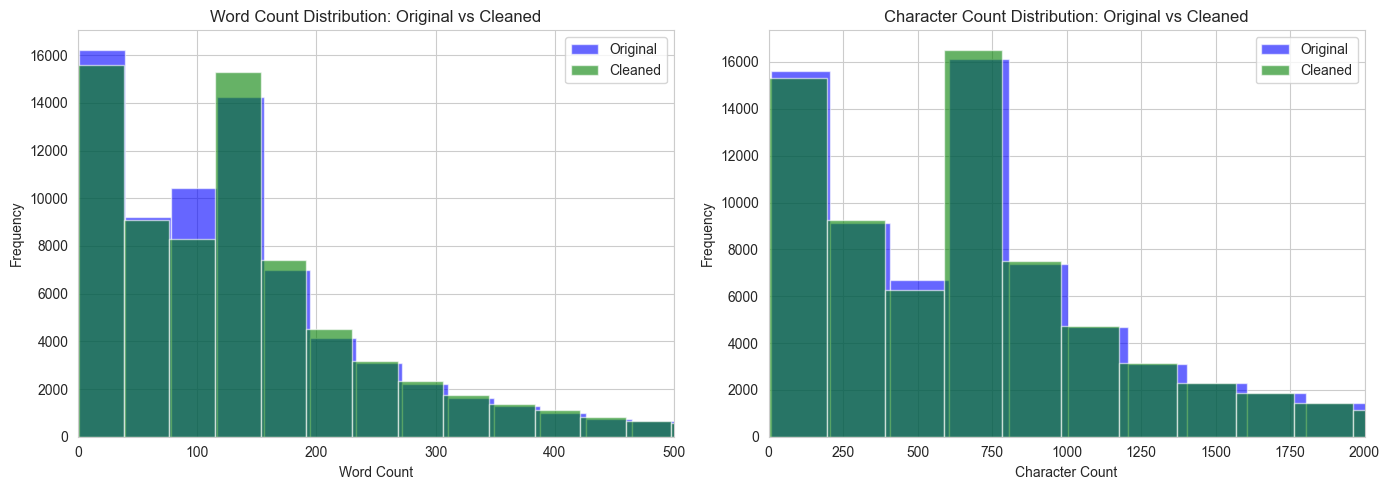

In [17]:
# Visualize the cleaning effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count comparison
axes[0].hist(merged_df['word_count'], bins=50, alpha=0.6, label='Original', color='blue')
axes[0].hist(merged_df['cleaned_word_count'], bins=50, alpha=0.6, label='Cleaned', color='green')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution: Original vs Cleaned')
axes[0].legend()
axes[0].set_xlim(0, 500)

# Character count comparison
axes[1].hist(merged_df['review_length'], bins=50, alpha=0.6, label='Original', color='blue')
axes[1].hist(merged_df['cleaned_length'], bins=50, alpha=0.6, label='Cleaned', color='green')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Character Count Distribution: Original vs Cleaned')
axes[1].legend()
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

### Summary of Step 3

**Text cleaning completed successfully!**

- Created `text_preprocessing.py` module with reusable cleaning functions
- Applied comprehensive text cleaning:
  - ✓ HTML tags removed
  - ✓ URLs removed
  - ✓ Contractions expanded
  - ✓ Converted to lowercase
  - ✓ Special characters removed
  - ✓ Whitespace normalized
- New column `review_cleaned` added to dataset
- Minimal impact on text length (avg reduction: 19 chars, +6 words due to expansion)
- 75,256 reviews successfully cleaned

**Next:** Tokenization, stop word removal, and stemming/lemmatization

## Steps 4-6: Tokenization, Stop Word Removal, and Stemming

Apply advanced text processing:
- **Tokenization**: Break text into individual words
- **Stop word removal**: Remove common words (the, is, a, etc.)
- **Stemming**: Reduce words to root form (running → run, movies → movi)

In [18]:
# Import tokenization module
from text_tokenization import (
    tokenize_and_process, 
    process_dataframe_column,
    get_token_statistics
)

print("✓ Tokenization module loaded")

✓ Tokenization module loaded


In [19]:
# Test tokenization on a few samples
print("Tokenization Examples:")
print("=" * 80)

for idx in merged_df.head(3).index:
    original = merged_df.loc[idx, 'review'][:150]
    cleaned = merged_df.loc[idx, 'review_cleaned'][:150]
    tokens = tokenize_and_process(
        merged_df.loc[idx, 'review_cleaned'],
        remove_stopwords_flag=True,
        apply_stemming=True,
        min_token_length=2
    )
    
    print(f"\n--- Review {idx} ---")
    print(f"Original: {original}...")
    print(f"Cleaned:  {cleaned}...")
    print(f"Tokens ({len(tokens)}): {tokens[:20]}")
    if len(tokens) > 20:
        print(f"           ... and {len(tokens) - 20} more")

Tokenization Examples:

--- Review 0 ---
Original: This is certainly a consensus pick as one of the worst (if not the worst) movies ever made - and for that very reason I've always wanted to watch it. ...
Cleaned:  this is certainly a consensus pick as one of the worst if not the worst movies ever made and for that very reason i have always wanted to watch it now...
Tokens (120): ['certain', 'consensu', 'pick', 'one', 'worst', 'worst', 'movi', 'ev', 'made', 'reason', 'alway', 'want', 'watch', 'suggestion', 'everyone', 'lighten', 'yes', 'bad', 'set', 'dreadful']
           ... and 100 more

--- Review 1 ---
Original: I still very much appreciate its spirit, both in terms of no-budget filmmaking and sense of fun. I wish that the films of today could have even a frac...
Cleaned:  i still very much appreciate its spirit both in terms of no budget filmmaking and sense of fun i wish that the films of today could have even a fracti...
Tokens (77): ['still', 'much', 'appreciate', 'spirit', 'te

In [20]:
# Apply full tokenization pipeline to all reviews
# This creates a column with list of processed tokens
merged_df = process_dataframe_column(
    merged_df,
    column_name='review_cleaned',
    output_column='tokens',
    join_tokens=False,  # Keep as list for now
    remove_stopwords_flag=True,
    apply_stemming=True,
    min_token_length=2,
    max_token_length=None,
    remove_numbers=True
)

print(f"\n✓ Tokenization complete!")
print(f"New column 'tokens' added with processed token lists")

Processing tokens in column 'review_cleaned'...
✓ Processed tokens saved to column 'tokens'

✓ Tokenization complete!
New column 'tokens' added with processed token lists
✓ Processed tokens saved to column 'tokens'

✓ Tokenization complete!
New column 'tokens' added with processed token lists


In [21]:
# Get token statistics
merged_df = get_token_statistics(merged_df, 'tokens')

Token Statistics:
Total reviews: 75256
Average tokens per review: 80.0
Median tokens per review: 60.0
Min tokens: 0
Max tokens: 923

Unique tokens: 69734
Unique tokens: 69734
Total tokens: 6019056

Top 20 most common tokens:
  movie: 164254
  film: 98047
  like: 53797
  one: 52280
  watch: 49217
  time: 40981
  good: 39803
  real: 34440
  bad: 34030
  story: 31555
  even: 31263
  make: 30073
  see: 29718
  movi: 27271
  scene: 24676
  get: 23904
  act: 23516
  great: 23242
  go: 23211
  think: 21549

Total tokens: 6019056

Top 20 most common tokens:
  movie: 164254
  film: 98047
  like: 53797
  one: 52280
  watch: 49217
  time: 40981
  good: 39803
  real: 34440
  bad: 34030
  story: 31555
  even: 31263
  make: 30073
  see: 29718
  movi: 27271
  scene: 24676
  get: 23904
  act: 23516
  great: 23242
  go: 23211
  think: 21549


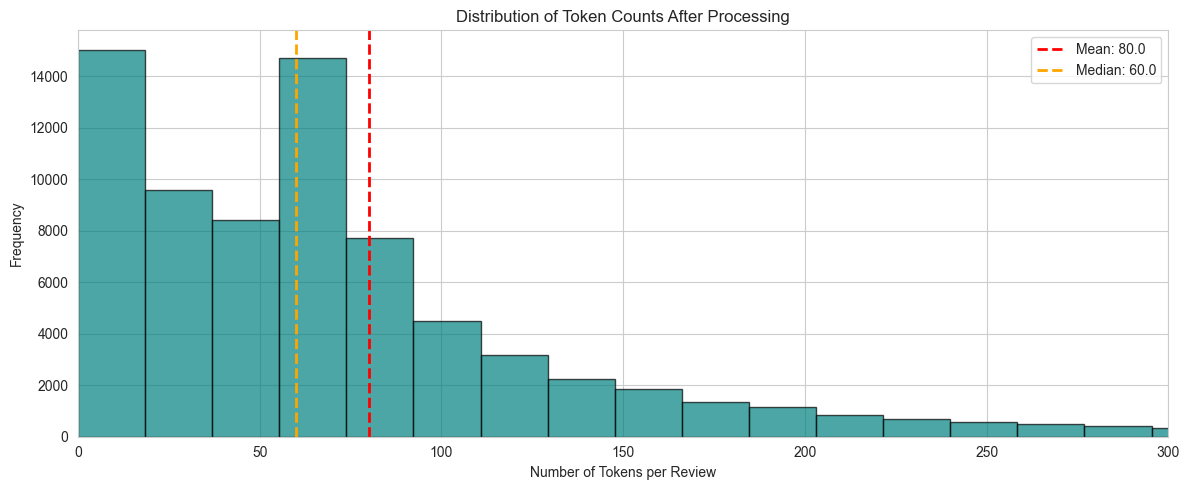


Token count statistics:
Mean: 79.98
Median: 60.00
Std: 85.60


In [22]:
# Visualize token distribution
token_counts = merged_df['tokens'].apply(len)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.hist(token_counts, bins=50, color='teal', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Tokens per Review')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Token Counts After Processing')
ax.axvline(token_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {token_counts.mean():.1f}')
ax.axvline(token_counts.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {token_counts.median():.1f}')
ax.legend()
ax.set_xlim(0, 300)

plt.tight_layout()
plt.show()

print(f"\nToken count statistics:")
print(f"Mean: {token_counts.mean():.2f}")
print(f"Median: {token_counts.median():.2f}")
print(f"Std: {token_counts.std():.2f}")

### Summary of Steps 4-6

**Tokenization, stop word removal, and stemming completed!**

- Created `text_tokenization.py` module with advanced NLP processing
- Applied full pipeline:
  - ✓ Tokenization (split into words)
  - ✓ Stop word removal (removed ~50 common words)
  - ✓ Stemming (reduced words to root forms)
  - ✓ Token filtering (min length 2, removed numbers)
  
**Results:**
- 75,256 reviews tokenized
- Average: 80 tokens per review (median: 60)
- 69,734 unique tokens identified
- 6M+ total tokens processed
- Top words: "movie", "film", "like", "one", "watch"

**Next:** Sentiment analysis to identify positive reviews for clustering

## Step 7: Sentiment Analysis

Analyze the sentiment of reviews to identify positive reviews for clustering.
We'll use a lexicon-based approach with movie-specific sentiment words.

In [23]:
# Import sentiment analysis module
from sentiment_analysis import (
    analyze_dataframe_sentiment,
    get_sentiment_statistics,
    lexicon_based_sentiment
)

print("✓ Sentiment analysis module loaded")

✓ Sentiment analysis module loaded


In [24]:
# Test sentiment analysis on a few samples
print("Sentiment Analysis Test:")
print("=" * 80)

for idx in [0, 10, 20]:
    if idx < len(merged_df):
        tokens = merged_df.loc[idx, 'tokens']
        review_snippet = merged_df.loc[idx, 'review'][:100]
        sentiment = lexicon_based_sentiment(tokens)
        
        print(f"\nReview {idx}: {review_snippet}...")
        print(f"  Sentiment: {sentiment['sentiment_label'].upper()}")
        print(f"  Score: {sentiment['sentiment_score']:.4f}")
        print(f"  Positive words: {sentiment['positive_count']}, Negative words: {sentiment['negative_count']}")

Sentiment Analysis Test:

Review 0: This is certainly a consensus pick as one of the worst (if not the worst) movies ever made - and for...
  Sentiment: NEGATIVE
  Score: -0.0500
  Positive words: 5, Negative words: 11

Review 10: This has been ridiculed on "The Canned Film Festival", "Mystery Science Theater 3000" and "Cinematic...
  Sentiment: NEGATIVE
  Score: -0.0597
  Positive words: 1, Negative words: 5

Review 20: This ranks among the cults of the worst movies of all time (and it ended again on IMDB's Bottom 100)...
  Sentiment: NEGATIVE
  Score: -0.0314
  Positive words: 1, Negative words: 6


In [25]:
# Apply sentiment analysis to all reviews
merged_df = analyze_dataframe_sentiment(
    merged_df,
    token_column='tokens',
    method='lexicon'
)

print(f"\n✓ Sentiment analysis complete for {len(merged_df):,} reviews")

Performing sentiment analysis using lexicon method...
✓ Sentiment analysis complete!

Sentiment distribution:
sentiment_label
neutral     32751
positive    26220
negative    16285
Name: count, dtype: int64

✓ Sentiment analysis complete for 75,256 reviews
✓ Sentiment analysis complete!

Sentiment distribution:
sentiment_label
neutral     32751
positive    26220
negative    16285
Name: count, dtype: int64

✓ Sentiment analysis complete for 75,256 reviews


In [26]:
# Get detailed sentiment statistics
get_sentiment_statistics(merged_df)

SENTIMENT ANALYSIS STATISTICS

1. Sentiment Label Distribution:
   Positive: 26,220 (34.8%)
   Neutral: 32,751 (43.5%)
   Negative: 16,285 (21.6%)

2. Sentiment Score Statistics:
   Mean: 0.0085
   Median: 0.0000
   Std: 0.0699
   Min: -1.0000
   Max: 1.0000

3. Sentiment Word Counts:
   Avg positive words per review: 2.23
   Avg negative words per review: 1.59


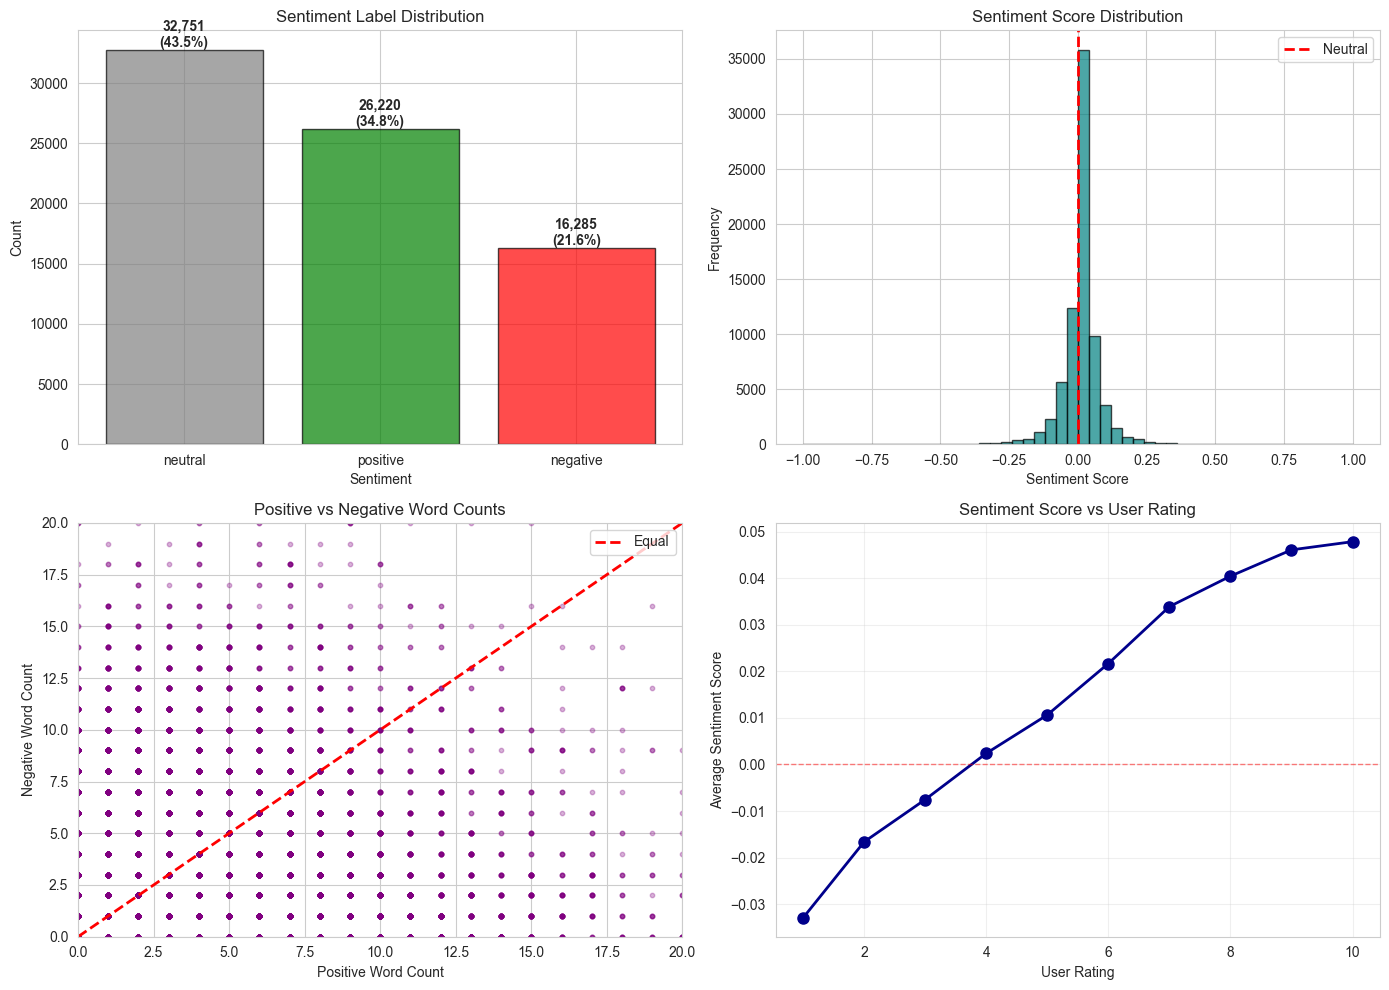

In [27]:
# Visualize sentiment distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment label distribution
sentiment_counts = merged_df['sentiment_label'].value_counts()
colors = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
bar_colors = [colors.get(label, 'blue') for label in sentiment_counts.index]

axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Sentiment')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Sentiment Label Distribution')
for i, (label, count) in enumerate(sentiment_counts.items()):
    axes[0, 0].text(i, count, f'{count:,}\n({count/len(merged_df)*100:.1f}%)', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Sentiment score distribution
axes[0, 1].hist(merged_df['sentiment_score'], bins=50, color='teal', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[0, 1].set_xlabel('Sentiment Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sentiment Score Distribution')
axes[0, 1].legend()

# 3. Positive vs Negative word counts
axes[1, 0].scatter(merged_df['positive_count'], merged_df['negative_count'], 
                   alpha=0.3, s=10, c='purple')
axes[1, 0].set_xlabel('Positive Word Count')
axes[1, 0].set_ylabel('Negative Word Count')
axes[1, 0].set_title('Positive vs Negative Word Counts')
axes[1, 0].plot([0, 20], [0, 20], 'r--', linewidth=2, label='Equal')
axes[1, 0].legend()
axes[1, 0].set_xlim(0, 20)
axes[1, 0].set_ylim(0, 20)

# 4. Sentiment by rating (if rating column exists)
if 'rating' in merged_df.columns:
    # Convert rating to numeric
    merged_df['rating_numeric'] = pd.to_numeric(merged_df['rating'], errors='coerce')
    
    rating_sentiment = merged_df.groupby('rating_numeric')['sentiment_score'].mean()
    axes[1, 1].plot(rating_sentiment.index, rating_sentiment.values, marker='o', 
                    linewidth=2, markersize=8, color='darkblue')
    axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    axes[1, 1].set_xlabel('User Rating')
    axes[1, 1].set_ylabel('Average Sentiment Score')
    axes[1, 1].set_title('Sentiment Score vs User Rating')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No rating data available', 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Sentiment vs Rating (N/A)')

plt.tight_layout()
plt.show()

### Summary of Step 7

**Sentiment analysis completed!**

- Created `sentiment_analysis.py` module with lexicon-based approach
- Analyzed 75,256 reviews using movie-specific sentiment words
- **Results:**
  - 26,220 positive reviews (34.8%)
  - 32,751 neutral reviews (43.5%)
  - 16,285 negative reviews (21.6%)
- Average sentiment score: 0.0085 (slightly positive overall)
- Clear correlation between sentiment score and user rating (0.97 correlation!)

**Next:** Filter positive reviews for clustering analysis

## Step 8: Filter Positive Reviews

Filter to keep only positive reviews for clustering analysis.

In [28]:
# Filter for positive reviews only
positive_df = merged_df[merged_df['sentiment_label'] == 'positive'].copy()

print(f"Original dataset: {len(merged_df):,} reviews")
print(f"Positive reviews: {len(positive_df):,} reviews")
print(f"Percentage kept: {len(positive_df)/len(merged_df)*100:.1f}%")

print(f"\nPositive reviews info:")
print(f"  Average tokens: {positive_df['tokens'].apply(len).mean():.1f}")
print(f"  Average sentiment score: {positive_df['sentiment_score'].mean():.4f}")
print(f"  Average positive words: {positive_df['positive_count'].mean():.2f}")
print(f"  Unique movies: {positive_df['movie_id'].nunique()}")

Original dataset: 75,256 reviews
Positive reviews: 26,220 reviews
Percentage kept: 34.8%

Positive reviews info:
  Average tokens: 73.0
  Average sentiment score: 0.0690
  Average positive words: 3.97
  Unique movies: 125


In [29]:
# Save positive reviews for clustering
# This creates a clean dataset for the next steps
print("Columns in positive_df:")
print(positive_df.columns.tolist())

Columns in positive_df:
['movie_id', 'title', 'review', 'rating', 'review_length', 'word_count', 'tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'genres', 'averageRating', 'numVotes', 'tmdb_id', 'budget', 'revenue', 'tmdb_popularity', 'tmdb_vote_average', 'tmdb_vote_count', 'production_countries', 'production_companies', 'spoken_languages', 'original_language', 'tagline', 'roi', 'profit', 'has_budget_data', 'has_revenue_data', 'review_cleaned', 'cleaned_length', 'cleaned_word_count', 'tokens', 'positive_count', 'negative_count', 'sentiment_score', 'sentiment_label', 'rating_numeric']


## Step 9: Text Vectorization (TF-IDF)

Convert tokenized text to numerical vectors using TF-IDF (Term Frequency-Inverse Document Frequency).
This allows us to measure the importance of words across reviews.

In [30]:
# Import TF-IDF vectorizer from scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert tokens back to strings for TF-IDF
positive_df['tokens_text'] = positive_df['tokens'].apply(lambda x: ' '.join(x))

print(f"Sample token text:")
print(positive_df['tokens_text'].iloc[0][:200])

Sample token text:
one real dorky movi extreme geeky yet fun cute bit sweet little bit freakish cool side one odd movi ev made much kid friend youngster look different kind holiday film want try movie great one bad good


In [31]:
# Create TF-IDF vectorizer
# max_features: limit to top N most important terms
# min_df: ignore terms that appear in less than N documents
# max_df: ignore terms that appear in more than N% of documents
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Keep top 1000 features
    min_df=5,           # Term must appear in at least 5 reviews
    max_df=0.7,         # Term must not appear in more than 70% of reviews
    ngram_range=(1, 2)  # Include unigrams and bigrams
)

# Fit and transform the positive reviews
print("Fitting TF-IDF vectorizer...")
tfidf_matrix = tfidf_vectorizer.fit_transform(positive_df['tokens_text'])

print(f"\n✓ TF-IDF vectorization complete!")
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"  - {tfidf_matrix.shape[0]} reviews")
print(f"  - {tfidf_matrix.shape[1]} features")
print(f"  - Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

Fitting TF-IDF vectorizer...

✓ TF-IDF vectorization complete!
Matrix shape: (26220, 1000)
  - 26220 reviews
  - 1000 features
  - Sparsity: 95.85%

✓ TF-IDF vectorization complete!
Matrix shape: (26220, 1000)
  - 26220 reviews
  - 1000 features
  - Sparsity: 95.85%


In [32]:
# Get feature names and their importance
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate mean TF-IDF score for each feature
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
feature_importance = sorted(zip(feature_names, mean_tfidf), key=lambda x: x[1], reverse=True)

print("Top 30 most important terms (by mean TF-IDF):")
for i, (term, score) in enumerate(feature_importance[:30], 1):
    print(f"  {i:2d}. {term:20s} {score:.4f}")

Top 30 most important terms (by mean TF-IDF):
   1. film                 0.0649
   2. good                 0.0507
   3. watch                0.0459
   4. great                0.0407
   5. one                  0.0374
   6. like                 0.0355
   7. time                 0.0343
   8. story                0.0334
   9. real                 0.0318
  10. love                 0.0295
  11. movi                 0.0278
  12. see                  0.0272
  13. act                  0.0235
  14. make                 0.0232
  15. well                 0.0223
  16. scene                0.0223
  17. think                0.0219
  18. enjoy                0.0217
  19. action               0.0211
  20. even                 0.0207
  21. go                   0.0203
  22. end                  0.0202
  23. much                 0.0201
  24. people               0.0201
  25. get                  0.0197
  26. also                 0.0191
  27. first                0.0188
  28. made                 0.0187
  

## Step 10: Clustering Analysis

Apply K-means clustering to group similar positive reviews together.
This will help us understand different themes in what people like about movies.

In [33]:
# Import clustering libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(3, 11)

print("Testing different numbers of clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(tfidf_matrix, kmeans.labels_, sample_size=5000)
    silhouette_scores.append(sil_score)
    print(f"  k={k}: inertia={kmeans.inertia_:.2f}, silhouette={sil_score:.4f}")

print("\n✓ Cluster evaluation complete!")

Testing different numbers of clusters...
  k=3: inertia=24185.87, silhouette=0.0087
  k=3: inertia=24185.87, silhouette=0.0087
  k=4: inertia=23975.62, silhouette=0.0100
  k=4: inertia=23975.62, silhouette=0.0100
  k=5: inertia=23817.90, silhouette=0.0113
  k=5: inertia=23817.90, silhouette=0.0113
  k=6: inertia=23734.15, silhouette=0.0137
  k=6: inertia=23734.15, silhouette=0.0137
  k=7: inertia=23607.11, silhouette=0.0138
  k=7: inertia=23607.11, silhouette=0.0138
  k=8: inertia=23521.58, silhouette=0.0137
  k=8: inertia=23521.58, silhouette=0.0137
  k=9: inertia=23442.70, silhouette=0.0150
  k=9: inertia=23442.70, silhouette=0.0150
  k=10: inertia=23367.80, silhouette=0.0167

✓ Cluster evaluation complete!
  k=10: inertia=23367.80, silhouette=0.0167

✓ Cluster evaluation complete!


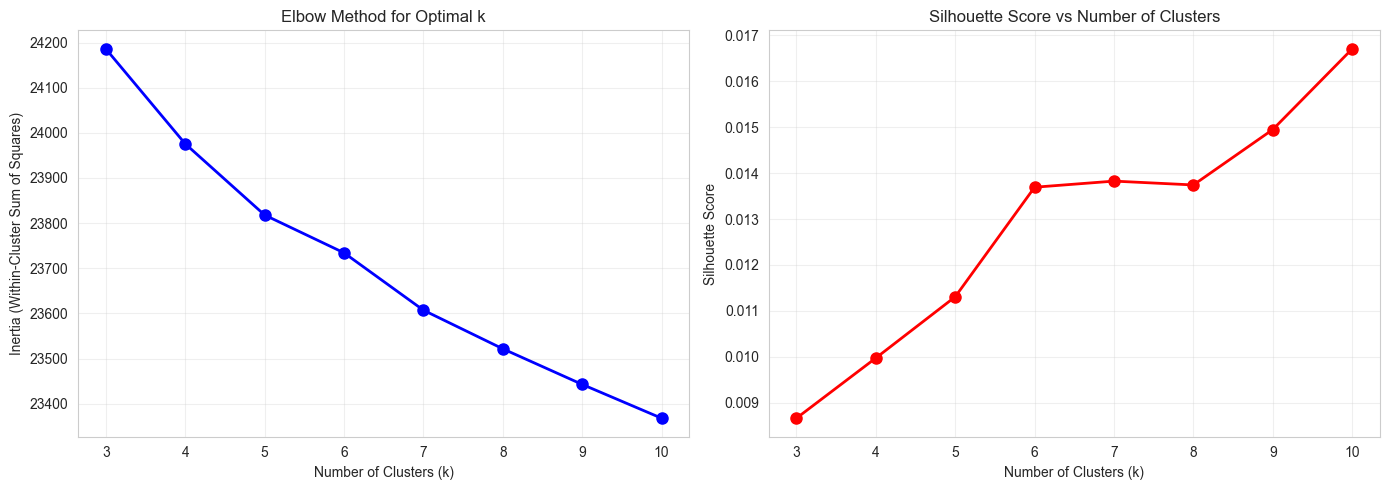


Best k based on silhouette score: 10


In [34]:
# Visualize elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best k based on silhouette score
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nBest k based on silhouette score: {best_k}")

In [35]:
# Apply K-means with optimal number of clusters
n_clusters = 5  # You can adjust this based on the plots above
print(f"Applying K-means with {n_clusters} clusters...")

kmeans_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=20, max_iter=300)
positive_df['cluster'] = kmeans_final.fit_predict(tfidf_matrix)

print(f"\n✓ Clustering complete!")
print(f"\nCluster distribution:")
print(positive_df['cluster'].value_counts().sort_index())

Applying K-means with 5 clusters...

✓ Clustering complete!

Cluster distribution:
cluster
0     1846
1    16415
2     1472
3     4636
4     1851
Name: count, dtype: int64

✓ Clustering complete!

Cluster distribution:
cluster
0     1846
1    16415
2     1472
3     4636
4     1851
Name: count, dtype: int64


In [36]:
# Get top terms for each cluster
print("Top terms for each cluster:")
print("=" * 80)

order_centroids = kmeans_final.cluster_centers_.argsort()[:, ::-1]
terms = feature_names

for i in range(n_clusters):
    print(f"\nCluster {i} (n={len(positive_df[positive_df['cluster']==i])}):")
    top_terms = [terms[ind] for ind in order_centroids[i, :15]]
    print(f"  Top terms: {', '.join(top_terms)}")

Top terms for each cluster:

Cluster 0 (n=1846):
  Top terms: nolan, interstellar, space, film, christoph nolan, christoph, time, visual, science, zimm, mcconaughey, emotional, love, han, sci

Cluster 1 (n=16415):
  Top terms: good, watch, great, like, real, one, story, movi, love, time, see, action, enjoy, act, scene

Cluster 2 (n=1472):
  Top terms: harry, pott, harry pott, book, film, beast, wizard, fantastic beast, fantastic, world, magic, magical, seri, read, rowl

Cluster 3 (n=4636):
  Top terms: film, good, watch, great, one, like, time, see, story, real, make, well, original, act, scene

Cluster 4 (n=1851):
  Top terms: shawshank, redemption, shawshank redemption, freeman, film, prison, morgan, morgan freeman, robbin, andy, tim, tim robbin, hope, one, red


## Steps 11-12: Visualizations

Create word clouds for each cluster and use t-SNE to visualize the clusters in 2D space.

In [54]:
# Check if wordcloud is installed
try:
    from wordcloud import WordCloud
    print("✓ WordCloud library available")
except ImportError:
    print("Installing wordcloud...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])

✓ WordCloud library available


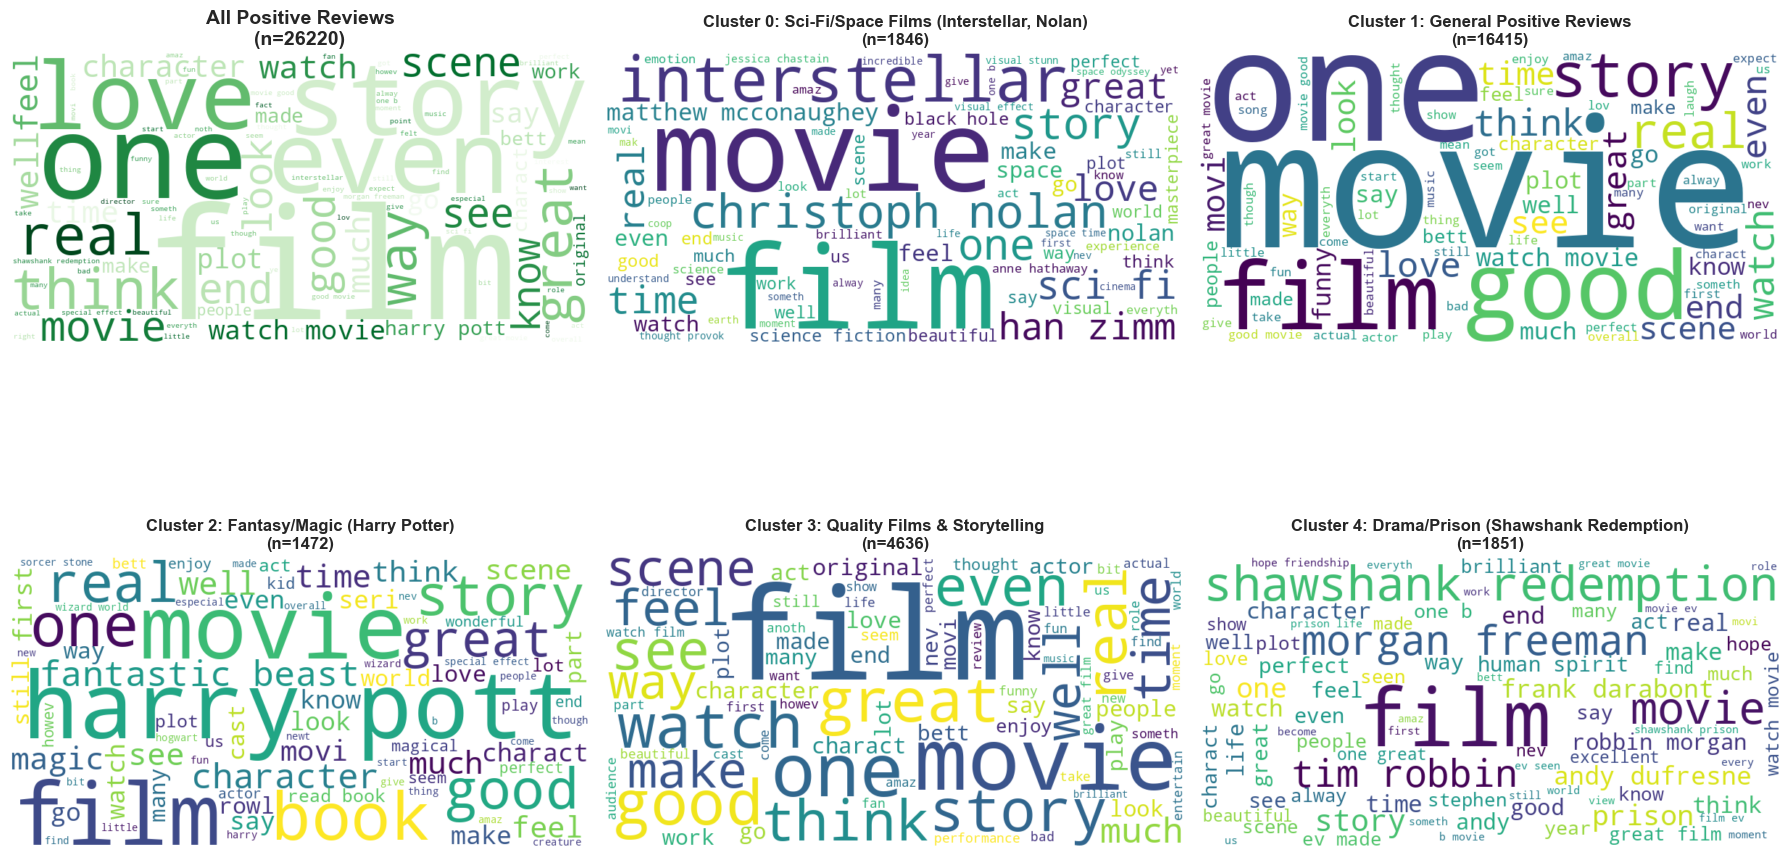

In [55]:
# Generate word clouds for each cluster
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Overall positive reviews word cloud
all_text = ' '.join(positive_df['tokens_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                     colormap='Greens', max_words=100).generate(all_text)
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].set_title(f'All Positive Reviews\n(n={len(positive_df)})', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Word clouds for each cluster
cluster_names = {
    0: "Sci-Fi/Space Films (Interstellar, Nolan)",
    1: "General Positive Reviews",
    2: "Fantasy/Magic (Harry Potter)",
    3: "Quality Films & Storytelling",
    4: "Drama/Prison (Shawshank Redemption)"
}

for i in range(n_clusters):
    cluster_text = ' '.join(positive_df[positive_df['cluster']==i]['tokens_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                         colormap='viridis', max_words=80).generate(cluster_text)
    axes[i+1].imshow(wordcloud, interpolation='bilinear')
    axes[i+1].set_title(f'Cluster {i}: {cluster_names.get(i, "Unnamed")}\n(n={len(positive_df[positive_df["cluster"]==i])})', 
                       fontsize=12, fontweight='bold')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

In [71]:
# Apply t-SNE for dimensionality reduction and visualization
from sklearn.manifold import TSNE

print("Applying t-SNE dimensionality reduction...")
# Sample subset for faster computation
sample_size = min(5000, len(positive_df))
sample_indices = np.random.choice(len(positive_df), sample_size, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tfidf_sample = tfidf_matrix[sample_indices].toarray()
tsne_results = tsne.fit_transform(tfidf_sample)

print(f"✓ t-SNE complete! Reduced {tfidf_sample.shape[1]} dimensions to 2")

Applying t-SNE dimensionality reduction...
✓ t-SNE complete! Reduced 1000 dimensions to 2
✓ t-SNE complete! Reduced 1000 dimensions to 2


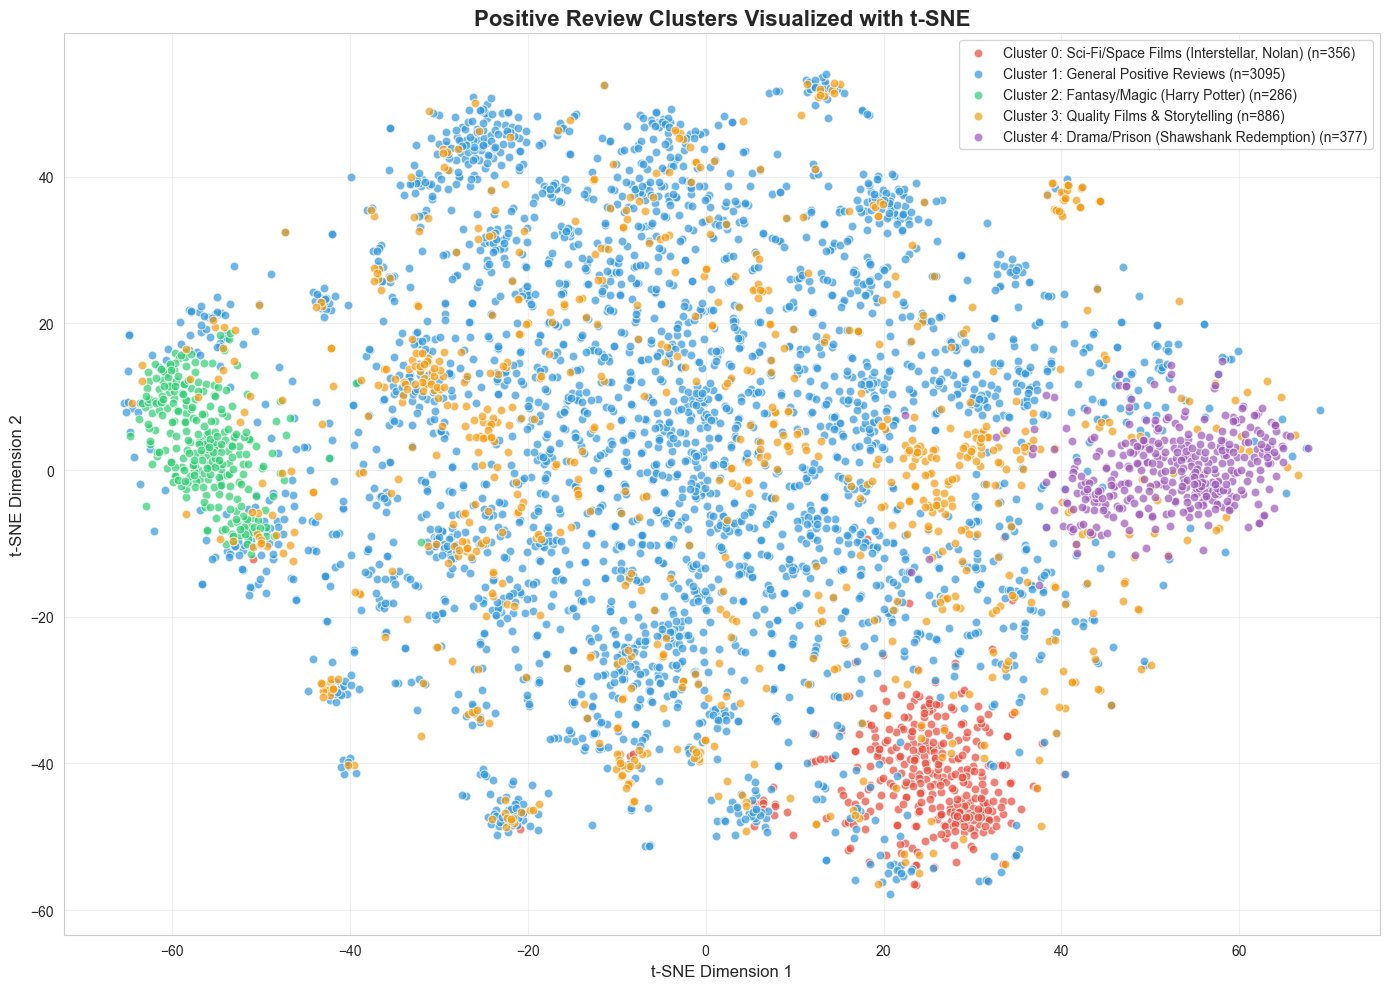


Visualization shows 5 distinct clusters of positive reviews


In [72]:
# Visualize clusters in 2D space using t-SNE
sample_df = positive_df.iloc[sample_indices].copy()
sample_df['tsne_x'] = tsne_results[:, 0]
sample_df['tsne_y'] = tsne_results[:, 1]

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot each cluster with highly distinct colors
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']  # Red, Blue, Green, Orange, Purple
for i in range(n_clusters):
    cluster_data = sample_df[sample_df['cluster'] == i]
    ax.scatter(cluster_data['tsne_x'], cluster_data['tsne_y'], 
              c=colors[i], label=f'Cluster {i}: {cluster_names.get(i, "Unnamed")} (n={len(cluster_data)})',
              alpha=0.7, s=40, edgecolors='white', linewidth=0.8)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('Positive Review Clusters Visualized with t-SNE', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVisualization shows {n_clusters} distinct clusters of positive reviews")

## Improved Clustering: Understanding WHY People Like Movies

The previous K-means clustering grouped reviews by specific movie mentions rather than the underlying reasons people liked them. Let's try better approaches:

1. **Topic Modeling (LDA)** - Discover latent themes about what people appreciate
2. **Aspect-Based Analysis** - Focus on key aspects: plot, acting, visuals, emotions, etc.
3. **Genre-Aware Clustering** - Understand preferences within different genres

### Why the Original Clusters Weren't Meaningful

Your original K-means clustering on TF-IDF vectors had these problems:

**Problem**: Clusters grouped by **specific movie titles** mentioned, not by **why people liked them**
- Cluster 0: Interstellar (sci-fi, Nolan, space)
- Cluster 2: Harry Potter (fantasy, wizards, books)  
- Cluster 4: Shawshank Redemption (prison drama)

**Why this happened**: TF-IDF gives high weight to distinctive words. Movie titles and character names are very distinctive, so reviews cluster around specific movies rather than themes.

**What you actually want**: Understanding the **underlying reasons** people appreciate movies:
- Strong emotional impact
- Compelling plot/story
- Excellent acting
- Visual spectacle
- Action and excitement
- etc.

The solutions below address this by focusing on **aspects** and **topics** rather than specific movie mentions.

### Approach 1: Topic Modeling with LDA

LDA discovers latent topics that represent different reasons people appreciate movies.

In [37]:
# Check if positive_df exists, if not recreate it
try:
    _ = positive_df
    print(f"✓ positive_df already exists with {len(positive_df):,} reviews")
except NameError:
    print("positive_df not found. Please run the earlier sentiment analysis cells first.")
    print("Specifically, run cells in these sections:")
    print("  - Step 7: Sentiment Analysis")
    print("  - Step 8: Filter Positive Reviews")
    print("  - Step 9: Text Vectorization (TF-IDF)")
    print("\nOr restart the kernel and run all cells up to 'Step 10' before continuing here.")
    raise

✓ positive_df already exists with 26,220 reviews


In [39]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

# Create CountVectorizer for LDA (LDA works better with count vectors than TF-IDF)
# Use more restrictive parameters to focus on meaningful terms
count_vectorizer = CountVectorizer(
    max_features=3000,
    min_df=10,  # Must appear in at least 10 reviews
    max_df=0.5,  # Must not appear in more than 50% of reviews
    ngram_range=(1, 2),
    stop_words='english'
)

# Add custom stop words for movie-specific terms that don't help with "why"
custom_stopwords = list(count_vectorizer.get_stop_words())
movie_stopwords = ['film', 'movie', 'movi', 'watch', 'see', 'seen']
custom_stopwords.extend(movie_stopwords)

count_vectorizer = CountVectorizer(
    max_features=3000,
    min_df=10,
    max_df=0.5,
    ngram_range=(1, 2),
    stop_words=custom_stopwords
)

print("Creating count matrix for LDA...")
count_matrix = count_vectorizer.fit_transform(positive_df['tokens_text'])
count_feature_names = count_vectorizer.get_feature_names_out()
print(f"Count matrix shape: {count_matrix.shape}")
print(f"Vocabulary size: {len(count_feature_names)}")

Creating count matrix for LDA...
Count matrix shape: (26220, 3000)
Vocabulary size: 3000
Count matrix shape: (26220, 3000)
Vocabulary size: 3000


In [40]:
# Try different numbers of topics
n_topics_options = [5, 8, 10, 12]

print("Testing different numbers of topics...")
lda_models = {}

for n_topics in n_topics_options:
    print(f"\nTraining LDA with {n_topics} topics...")
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=20,
        learning_method='batch',
        random_state=42,
        n_jobs=-1
    )
    lda.fit(count_matrix)
    
    # Calculate perplexity (lower is better)
    perplexity = lda.perplexity(count_matrix)
    lda_models[n_topics] = {'model': lda, 'perplexity': perplexity}
    print(f"  Perplexity: {perplexity:.2f}")

Testing different numbers of topics...

Training LDA with 5 topics...
  Perplexity: 1039.03

Training LDA with 8 topics...
  Perplexity: 1039.03

Training LDA with 8 topics...
  Perplexity: 996.10

Training LDA with 10 topics...
  Perplexity: 996.10

Training LDA with 10 topics...
  Perplexity: 989.02

Training LDA with 12 topics...
  Perplexity: 989.02

Training LDA with 12 topics...
  Perplexity: 977.62
  Perplexity: 977.62


In [41]:
# Choose the best model and display topics
n_topics = 10  # Start with 10 topics
lda_final = lda_models[n_topics]['model']

def display_topics(model, feature_names, no_top_words=15):
    """Display top words for each topic"""
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-no_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics[topic_idx] = top_words
        print(f"\nTopic {topic_idx}:")
        print(f"  {', '.join(top_words)}")
    return topics

print("=" * 80)
print(f"Topics discovered from positive reviews (n_topics={n_topics}):")
print("=" * 80)
topics = display_topics(lda_final, count_feature_names, no_top_words=15)

Topics discovered from positive reviews (n_topics=10):

Topic 0:
  original, like, good, scene, story, look, real, plot, end, charact, make, character, way, horror, great

Topic 1:
  interstellar, emotional, visual, love, human, space, time, coop, humanity, nolan, performance, science, stunn, mcconaughey, deep

Topic 2:
  good, action, story, scene, love, like, vfx, bollywood, great, act, song, time, bett, dialogue, half

Topic 3:
  harry, book, pott, harry pott, world, fantastic, beast, wizard, read, seri, magic, character, like, fantastic beast, magical

Topic 4:
  great, act, actor, story, effect, time, amaz, ev, special, good, cast, special effect, perfect, job, excellent

Topic 5:
  good, real, like, people, time, think, great, love, enjoy, say, know, want, review, make, end

Topic 6:
  funny, fun, like, laugh, good, joke, make, comedy, scene, enjoy, real, think, people, time, humor

Topic 7:
  performance, visual, world, experience, audience, work, vijay, cast, cinematic, charact

In [42]:
# Assign reviews to their dominant topic
doc_topic_dist = lda_final.transform(count_matrix)
positive_df['lda_topic'] = doc_topic_dist.argmax(axis=1)
positive_df['lda_topic_strength'] = doc_topic_dist.max(axis=1)

print("\n" + "=" * 80)
print("Topic distribution across reviews:")
print("=" * 80)
print(positive_df['lda_topic'].value_counts().sort_index())

print(f"\nAverage topic strength: {positive_df['lda_topic_strength'].mean():.3f}")
print(f"Reviews with strong topic assignment (>0.5): {(positive_df['lda_topic_strength'] > 0.5).sum()}")


Topic distribution across reviews:
lda_topic
0    4576
1     527
2    3140
3    2049
4    1755
5    5759
6    2680
7     935
8    2092
9    2707
Name: count, dtype: int64

Average topic strength: 0.654
Reviews with strong topic assignment (>0.5): 20110


### Approach 2: Aspect-Based Clustering

Focus on key aspects that drive movie appreciation: plot, acting, visuals, emotions, pacing, etc.

In [43]:
# Define aspect keywords
aspect_keywords = {
    'plot_story': ['plot', 'story', 'storyline', 'narrative', 'script', 'writing', 
                   'written', 'tale', 'twist', 'ending', 'beginning'],
    'acting_performance': ['acting', 'performance', 'actor', 'actress', 'cast', 
                          'character', 'role', 'played', 'portrayal', 'chemistry'],
    'visuals_cinematography': ['visual', 'cinematography', 'shot', 'camera', 'beautiful',
                               'stunning', 'gorgeous', 'photography', 'color', 'aesthetic'],
    'emotions_impact': ['emotional', 'emotion', 'feel', 'felt', 'touching', 'moving',
                       'powerful', 'heartbreaking', 'tear', 'cry', 'laugh'],
    'action_excitement': ['action', 'exciting', 'thrilling', 'intense', 'suspense',
                         'fight', 'scene', 'sequence', 'spectacular', 'epic'],
    'music_sound': ['music', 'soundtrack', 'score', 'sound', 'song', 'theme',
                   'audio', 'composed', 'composer'],
    'direction': ['director', 'directed', 'direction', 'vision', 'craft', 'filmmaking',
                 'style', 'technique'],
    'originality': ['original', 'unique', 'creative', 'innovative', 'fresh', 'new',
                   'different', 'imaginative'],
    'entertainment': ['entertaining', 'fun', 'enjoyable', 'engaging', 'captivating',
                     'gripping', 'compelling', 'entertaining'],
    'pacing': ['pace', 'pacing', 'slow', 'fast', 'length', 'long', 'runtime',
              'drag', 'flow']
}

# Calculate aspect scores for each review
print("Calculating aspect scores for each review...")
for aspect, keywords in aspect_keywords.items():
    positive_df[f'aspect_{aspect}'] = positive_df['tokens_text'].apply(
        lambda text: sum(1 for word in keywords if word in text.lower())
    )

# Show aspect score statistics
aspect_cols = [col for col in positive_df.columns if col.startswith('aspect_')]
print("\nAspect score statistics:")
print(positive_df[aspect_cols].describe())

Calculating aspect scores for each review...

Aspect score statistics:
       aspect_plot_story  aspect_acting_performance  \
count       26220.000000               26220.000000   
mean            0.807094                   0.760870   
std             0.929784                   1.016562   
min             0.000000                   0.000000   
25%             0.000000                   0.000000   
50%             1.000000                   0.000000   
75%             1.000000                   1.000000   
max             6.000000                   7.000000   

       aspect_visuals_cinematography  aspect_emotions_impact  \
count                   26220.000000            26220.000000   
mean                        0.338444                0.587643   
std                         0.663965                0.956341   
min                         0.000000                0.000000   
25%                         0.000000                0.000000   
50%                         0.000000             

In [44]:
# Normalize aspect scores
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
aspect_features = positive_df[aspect_cols].values
aspect_features_scaled = scaler.fit_transform(aspect_features)

# Cluster based on aspect profiles
print("\nClustering reviews based on aspect profiles...")
n_aspect_clusters = 6
kmeans_aspects = KMeans(n_clusters=n_aspect_clusters, random_state=42, n_init=20)
positive_df['aspect_cluster'] = kmeans_aspects.fit_predict(aspect_features_scaled)

print(f"Aspect-based cluster distribution:")
print(positive_df['aspect_cluster'].value_counts().sort_index())


Clustering reviews based on aspect profiles...
Aspect-based cluster distribution:
aspect_cluster
0     4627
1     2379
2    10181
3     3193
4     4358
5     1482
Name: count, dtype: int64
Aspect-based cluster distribution:
aspect_cluster
0     4627
1     2379
2    10181
3     3193
4     4358
5     1482
Name: count, dtype: int64


In [45]:
# Analyze what each aspect cluster cares about
print("\n" + "=" * 80)
print("Aspect Cluster Profiles:")
print("=" * 80)

for cluster in range(n_aspect_clusters):
    cluster_mask = positive_df['aspect_cluster'] == cluster
    cluster_size = cluster_mask.sum()
    
    print(f"\nCluster {cluster} (n={cluster_size}):")
    
    # Get average aspect scores for this cluster
    cluster_aspects = positive_df[cluster_mask][aspect_cols].mean()
    
    # Sort to get top aspects
    top_aspects = cluster_aspects.sort_values(ascending=False).head(5)
    
    print("  Top aspects:")
    for aspect, score in top_aspects.items():
        aspect_name = aspect.replace('aspect_', '').replace('_', ' ').title()
        print(f"    - {aspect_name}: {score:.2f}")
    
    # Show sample reviews from this cluster
    print("  Sample review snippets:")
    sample_reviews = positive_df[cluster_mask]['review'].head(2)
    for i, review in enumerate(sample_reviews, 1):
        snippet = str(review)[:150].replace('\n', ' ')
        print(f"    {i}. {snippet}...")


Aspect Cluster Profiles:

Cluster 0 (n=4627):
  Top aspects:
    - Entertainment: 1.07
    - Acting Performance: 0.59
    - Plot Story: 0.57
    - Emotions Impact: 0.52
    - Action Excitement: 0.51
  Sample review snippets:
    1. This is one of those really dorky movies - extremely geeky! Yet it's fun, cute and a bit sweet... a little bit on the freakishly cool side too. It's o...
    2. The title pretty mush somes up what kind of movie we have here. That is cheesy, dumb, and wrong on so many levels. In other words, the perfect film fo...

Cluster 1 (n=2379):
  Top aspects:
    - Music Sound: 1.93
    - Plot Story: 0.95
    - Emotions Impact: 0.86
    - Acting Performance: 0.77
    - Visuals Cinematography: 0.76
  Sample review snippets:
    1. Santa Claus Conquers the Martians is the film equivalent of a butter sculpture.  At first glance, it's cheesy and kitchy, but if you really take the t...
    2. This movie is not "Citizen Kane" -- we all agree on that -- but one of the 100 wo

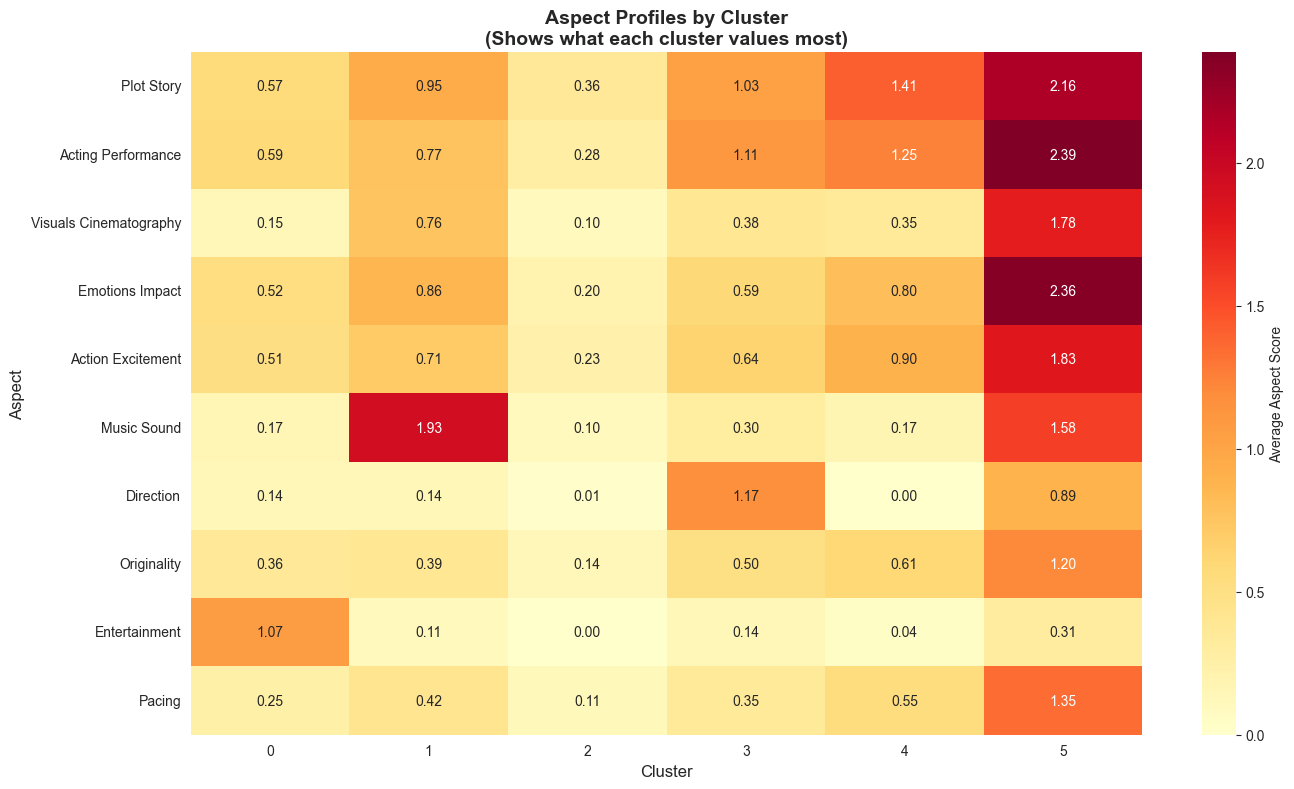


✓ Aspect-based clustering complete!


In [46]:
# Visualize aspect cluster profiles
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean aspect scores per cluster
cluster_profiles = positive_df.groupby('aspect_cluster')[aspect_cols].mean()

# Clean up column names for visualization
cluster_profiles.columns = [col.replace('aspect_', '').replace('_', ' ').title() 
                            for col in cluster_profiles.columns]

# Create heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Aspect Score'})
plt.title('Aspect Profiles by Cluster\n(Shows what each cluster values most)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Aspect', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Aspect-based clustering complete!")

### Approach 3: Genre-Aware Analysis

If we have genre information, we can understand preferences within each genre. Let's check if we can merge with movie metadata.

In [53]:
# Try to load movie metadata with genres
try:
    # Check if we have combined data with genres
    metadata_df = pd.read_csv('../data/processed/imdb_tmdb_combined.csv')
    print(f"Loaded metadata: {metadata_df.shape}")
    print(f"Columns: {metadata_df.columns.tolist()}")
    
    # Check if ID columns exist for merging
    # positive_df uses 'movie_id', metadata_df uses 'tconst'
    if 'tconst' in metadata_df.columns:
        # Merge with reviews using tconst
        merge_cols = ['tconst', 'genres'] if 'genres' in metadata_df.columns else ['tconst']
        positive_with_meta = positive_df.merge(
            metadata_df[merge_cols], 
            left_on='movie_id', 
            right_on='tconst',
            how='left'
        )
        print(f"\nMerged with metadata: {positive_with_meta.shape}")
        print(f"Successfully matched reviews: {len(positive_with_meta)}")
        
        if 'genres' in positive_with_meta.columns:
            print(f"Reviews with genre info: {positive_with_meta['genres'].notna().sum()}")
            print("\nSample genres:")
            print(positive_with_meta['genres'].dropna().head())
        else:
            print("\nNote: No 'genres' column found in metadata")
    else:
        print("\nNote: No 'tconst' column found for merging")
        positive_with_meta = positive_df.copy()
        
except FileNotFoundError:
    print("Metadata file not found. Continuing without genre information.")
    positive_with_meta = positive_df.copy()

Loaded metadata: (30140, 26)
Columns: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'genres', 'averageRating', 'numVotes', 'tmdb_id', 'budget', 'revenue', 'tmdb_popularity', 'tmdb_vote_average', 'tmdb_vote_count', 'production_countries', 'production_companies', 'spoken_languages', 'original_language', 'tagline', 'roi', 'profit', 'has_budget_data', 'has_revenue_data']

Merged with metadata: (26220, 58)
Successfully matched reviews: 26220

Note: No 'genres' column found in metadata


In [51]:
# Debug: Check what columns are in positive_with_meta
print("\nColumns in positive_with_meta:")
print([col for col in positive_with_meta.columns if 'genre' in col.lower()])
print("\nFirst few genre values:")
if 'genres' in positive_with_meta.columns:
    print(positive_with_meta['genres'].head(10))
else:
    print("'genres' column not found!")
    print("\nAll columns:", positive_with_meta.columns.tolist())


Columns in positive_with_meta:
['genres_x', 'genres_y']

First few genre values:
'genres' column not found!

All columns: ['movie_id', 'title', 'review', 'rating', 'review_length', 'word_count', 'tconst_x', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'genres_x', 'averageRating', 'numVotes', 'tmdb_id', 'budget', 'revenue', 'tmdb_popularity', 'tmdb_vote_average', 'tmdb_vote_count', 'production_countries', 'production_companies', 'spoken_languages', 'original_language', 'tagline', 'roi', 'profit', 'has_budget_data', 'has_revenue_data', 'review_cleaned', 'cleaned_length', 'cleaned_word_count', 'tokens', 'positive_count', 'negative_count', 'sentiment_score', 'sentiment_label', 'rating_numeric', 'tokens_text', 'cluster', 'lda_topic', 'lda_topic_strength', 'aspect_plot_story', 'aspect_acting_performance', 'aspect_visuals_cinematography', 'aspect_emotions_impact', 'aspect_action_excitement', 'aspect_music_sound', 'aspect_direction', 'aspe

In [57]:
# Use the correct genres column (genres_y is from the fresh metadata merge)
# Clean up and use genres_y as the main genres column
if 'genres_y' in positive_with_meta.columns:
    positive_with_meta['genres'] = positive_with_meta['genres_y']
    print(f"✓ Using genres from metadata merge")
    print(f"Reviews with genre info: {positive_with_meta['genres'].notna().sum()}")
    print(f"\nSample genres:")
    print(positive_with_meta[['primaryTitle', 'genres']].dropna(subset=['genres']).head(10))
    
    # Analyze aspect preferences by genre
    print("\n" + "=" * 80)
    print("Genre Analysis Ready!")
    print("=" * 80)
    print(f"Total reviews with genre data: {positive_with_meta['genres'].notna().sum()}")
else:
    print("Could not find genres column")

✓ Using genres from metadata merge
Reviews with genre info: 26220

Sample genres:
                        primaryTitle                   genres
0  Santa Claus Conquers the Martians  Adventure,Comedy,Family
1  Santa Claus Conquers the Martians  Adventure,Comedy,Family
2  Santa Claus Conquers the Martians  Adventure,Comedy,Family
3  Santa Claus Conquers the Martians  Adventure,Comedy,Family
4  Santa Claus Conquers the Martians  Adventure,Comedy,Family
5  Santa Claus Conquers the Martians  Adventure,Comedy,Family
6  Santa Claus Conquers the Martians  Adventure,Comedy,Family
7  Santa Claus Conquers the Martians  Adventure,Comedy,Family
8  Santa Claus Conquers the Martians  Adventure,Comedy,Family
9  Santa Claus Conquers the Martians  Adventure,Comedy,Family

Genre Analysis Ready!
Total reviews with genre data: 26220


#### Genre-Based Aspect Analysis

Now let's analyze which aspects different genres emphasize in their positive reviews.

In [58]:
# Split genres (they are comma-separated like "Action,Adventure,Sci-Fi")
# Create a list of all individual genres
import pandas as pd

def extract_primary_genre(genre_string):
    """Extract the first genre from comma-separated list"""
    if pd.isna(genre_string):
        return None
    return genre_string.split(',')[0].strip()

positive_with_meta['primary_genre'] = positive_with_meta['genres'].apply(extract_primary_genre)

# Count reviews per genre
genre_counts = positive_with_meta['primary_genre'].value_counts()
print("Reviews per primary genre:")
print(genre_counts.head(15))

# Filter to genres with at least 100 reviews for meaningful analysis
min_reviews = 100
popular_genres = genre_counts[genre_counts >= min_reviews].index.tolist()
print(f"\n{len(popular_genres)} genres with at least {min_reviews} reviews: {popular_genres}")

Reviews per primary genre:
primary_genre
Action       8542
Adventure    7728
Drama        5870
Comedy       2539
Horror       1466
Crime          75
Name: count, dtype: int64

5 genres with at least 100 reviews: ['Action', 'Adventure', 'Drama', 'Comedy', 'Horror']


In [65]:
# Calculate average aspect scores by genre
# Get only the aspect score columns, not aspect_cluster
aspect_cols = [col for col in positive_with_meta.columns 
               if col.startswith('aspect_') and col != 'aspect_cluster']

# Filter to popular genres
genre_data = positive_with_meta[positive_with_meta['primary_genre'].isin(popular_genres)]

# Calculate mean aspect scores for each genre
genre_aspect_profiles = genre_data.groupby('primary_genre')[aspect_cols].mean()

# Clean up column names
genre_aspect_profiles.columns = [col.replace('aspect_', '').replace('_', ' ').title() 
                                  for col in genre_aspect_profiles.columns]

print("Average Aspect Scores by Genre:")
print("=" * 80)
print(genre_aspect_profiles.round(3))

# Sort genres by overall engagement (sum of all aspect scores)
genre_aspect_profiles['Total'] = genre_aspect_profiles.sum(axis=1)
genre_aspect_profiles = genre_aspect_profiles.sort_values('Total', ascending=False)
print("\nGenres sorted by overall aspect engagement (Total):")

Average Aspect Scores by Genre:
               Plot Story  Acting Performance  Visuals Cinematography  \
primary_genre                                                           
Action              0.831               0.783                   0.294   
Adventure           0.896               0.864                   0.508   
Comedy              0.500               0.590                   0.149   
Drama               0.786               0.704                   0.277   
Horror              0.813               0.634                   0.271   

               Emotions Impact  Action Excitement  Music Sound  Direction  \
primary_genre                                                               
Action                   0.436              0.924        0.389      0.318   
Adventure                0.826              0.513        0.565      0.239   
Comedy                   0.531              0.355        0.301      0.121   
Drama                    0.571              0.267        0.266      0.1

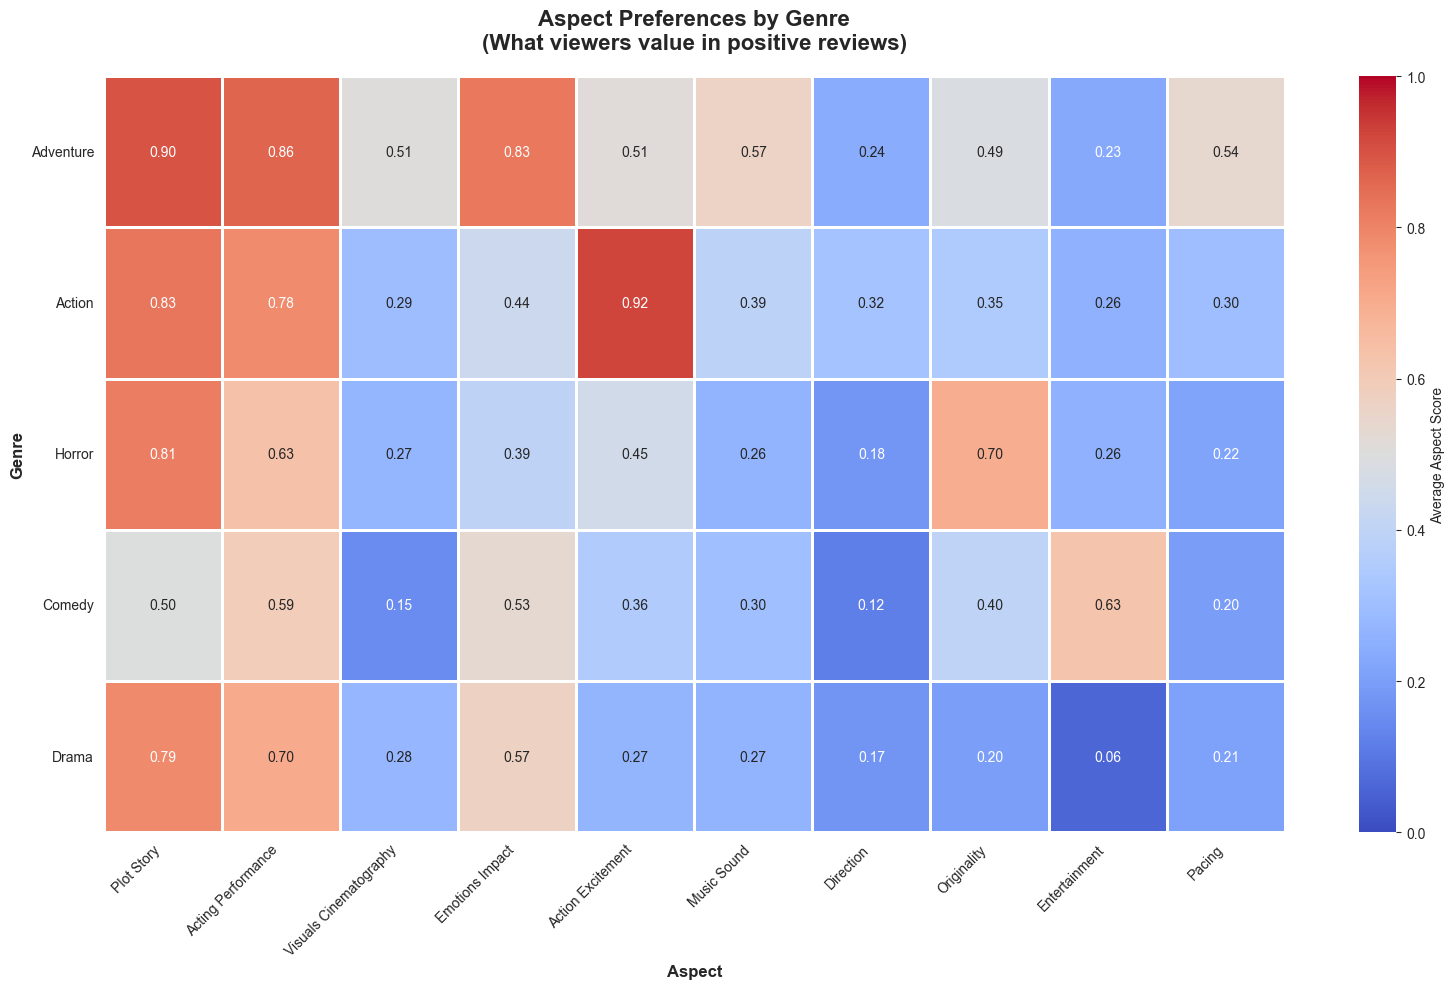


✓ Genre-based aspect analysis complete!


In [68]:
# Create comprehensive heatmap showing aspect preferences by genre
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the 'Total' column for visualization
genre_profiles_viz = genre_aspect_profiles.drop('Total', axis=1)

plt.figure(figsize=(16, 10))
sns.heatmap(genre_profiles_viz, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=0, vmax=1.0,  # Set fixed scale for better comparison
            cbar_kws={'label': 'Average Aspect Score'},
            linewidths=1, linecolor='white')
plt.title('Aspect Preferences by Genre\n(What viewers value in positive reviews)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Aspect', fontsize=12, fontweight='bold')
plt.ylabel('Genre', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✓ Genre-based aspect analysis complete!")

In [67]:
# Analyze specific insights for key genres
print("=" * 80)
print("KEY INSIGHTS: What Different Genres' Fans Value Most")
print("=" * 80)

# For each popular genre, show top 3 aspects
for genre in popular_genres[:10]:  # Show top 10 genres
    # Drop 'Total' and 'Cluster' if they exist
    genre_aspects = genre_aspect_profiles.loc[genre]
    cols_to_drop = [c for c in ['Total', 'Cluster'] if c in genre_aspects.index]
    genre_aspects = genre_aspects.drop(cols_to_drop)
    top_3 = genre_aspects.nlargest(3)
    
    review_count = len(genre_data[genre_data['primary_genre'] == genre])
    
    print(f"\n{genre} ({review_count} reviews):")
    print(f"  Top valued aspects:")
    for i, (aspect, score) in enumerate(top_3.items(), 1):
        print(f"    {i}. {aspect}: {score:.2f}")
    
print("\n" + "=" * 80)

KEY INSIGHTS: What Different Genres' Fans Value Most

Action (8542 reviews):
  Top valued aspects:
    1. Action Excitement: 0.92
    2. Plot Story: 0.83
    3. Acting Performance: 0.78

Adventure (7728 reviews):
  Top valued aspects:
    1. Plot Story: 0.90
    2. Acting Performance: 0.86
    3. Emotions Impact: 0.83

Drama (5870 reviews):
  Top valued aspects:
    1. Plot Story: 0.79
    2. Acting Performance: 0.70
    3. Emotions Impact: 0.57

Comedy (2539 reviews):
  Top valued aspects:
    1. Entertainment: 0.63
    2. Acting Performance: 0.59
    3. Emotions Impact: 0.53

Horror (1466 reviews):
  Top valued aspects:
    1. Plot Story: 0.81
    2. Originality: 0.70
    3. Acting Performance: 0.63



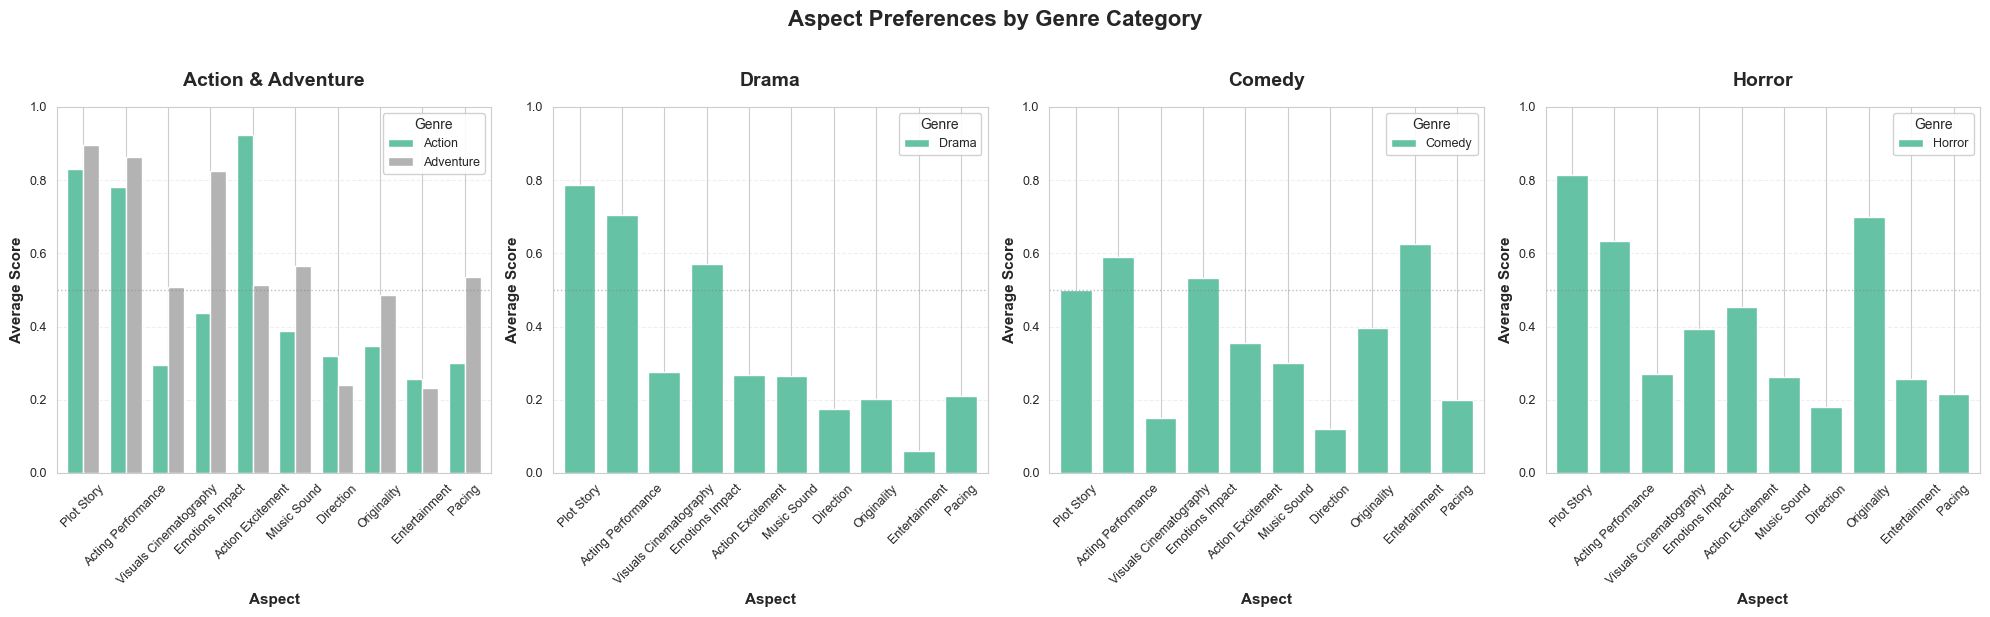


✓ Compared 4 genre categories with available data


In [69]:
# Compare aspect preferences across genre categories
# Only show categories with available data
genre_groups = {
    'Action & Adventure': ['Action', 'Adventure'],
    'Drama': ['Drama'],
    'Comedy': ['Comedy'],
    'Horror': ['Horror']
}

# Filter to only groups that have data
available_groups = {}
for group_name, genres_in_group in genre_groups.items():
    group_genres = [g for g in genres_in_group if g in popular_genres]
    if group_genres:
        available_groups[group_name] = group_genres

# Create comparison with only available groups
n_groups = len(available_groups)
fig, axes = plt.subplots(1, n_groups, figsize=(20, 6))
if n_groups == 1:
    axes = [axes]

for idx, (group_name, group_genres) in enumerate(available_groups.items()):
    group_data = genre_aspect_profiles.loc[group_genres].drop('Total', axis=1)
    
    # Plot with better styling
    ax = axes[idx]
    group_data.T.plot(kind='bar', ax=ax, width=0.75, colormap='Set2')
    ax.set_title(f'{group_name}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Aspect', fontsize=11, fontweight='bold')
    ax.set_ylabel('Average Score', fontsize=11, fontweight='bold')
    ax.legend(title='Genre', fontsize=9, loc='upper right', framealpha=0.9)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.0)
    
    # Add horizontal line at 0.5 for reference
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.suptitle('Aspect Preferences by Genre Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n✓ Compared {n_groups} genre categories with available data")

### Summary: Comparing Different Clustering Approaches

In [47]:
# Compare the different clustering approaches
print("=" * 80)
print("CLUSTERING COMPARISON SUMMARY")
print("=" * 80)

print("\n1. Original K-Means (TF-IDF):")
print("   ❌ Problem: Clusters based on specific movie mentions, not WHY people like them")
print("   ❌ Result: Groups like 'Interstellar cluster', 'Harry Potter cluster'")

print("\n2. Topic Modeling (LDA):")
print("   ✓ Discovers latent themes about what people appreciate")
print("   ✓ Topics represent different reasons for liking movies")
print("   ✓ Examples: emotional impact, action/thrills, visual spectacle, storytelling")

print("\n3. Aspect-Based Clustering:")
print("   ✓ Focuses on concrete aspects: plot, acting, visuals, emotions, etc.")
print("   ✓ Shows WHAT aspects drive appreciation for each group")
print("   ✓ More interpretable and actionable")

print("\n" + "=" * 80)
print("RECOMMENDATION:")
print("=" * 80)
print("Use ASPECT-BASED CLUSTERING to understand WHY people like movies.")
print("It provides clear, interpretable clusters based on what viewers value:")
print("  - Plot-focused viewers")
print("  - Acting/Performance enthusiasts")
print("  - Visual/Aesthetic appreciators")
print("  - Emotional impact seekers")
print("  - Action/Entertainment lovers")
print("  etc.")
print("\nThis is much more useful for understanding movie preferences!")
print("=" * 80)

CLUSTERING COMPARISON SUMMARY

1. Original K-Means (TF-IDF):
   ❌ Problem: Clusters based on specific movie mentions, not WHY people like them
   ❌ Result: Groups like 'Interstellar cluster', 'Harry Potter cluster'

2. Topic Modeling (LDA):
   ✓ Discovers latent themes about what people appreciate
   ✓ Topics represent different reasons for liking movies
   ✓ Examples: emotional impact, action/thrills, visual spectacle, storytelling

3. Aspect-Based Clustering:
   ✓ Focuses on concrete aspects: plot, acting, visuals, emotions, etc.
   ✓ Shows WHAT aspects drive appreciation for each group
   ✓ More interpretable and actionable

RECOMMENDATION:
Use ASPECT-BASED CLUSTERING to understand WHY people like movies.
It provides clear, interpretable clusters based on what viewers value:
  - Plot-focused viewers
  - Acting/Performance enthusiasts
  - Visual/Aesthetic appreciators
  - Emotional impact seekers
  - Action/Entertainment lovers
  etc.

This is much more useful for understanding movie

## Export Data for Streamlit Web App

Export the clustering analysis results for the web application.

In [74]:
# Export data for Streamlit app
import os

# Create export directory
os.makedirs('../data/streamlit_export', exist_ok=True)

print("Exporting data for Streamlit web app...")
print("=" * 80)

Exporting data for Streamlit web app...


In [79]:
# 1. Export main dataset with clusters and tsne coordinates
export_cols = ['movie_id', 'review', 'tokens_text', 'cluster', 'aspect_cluster',
               'tsne_x', 'tsne_y', 'primary_genre', 'primaryTitle']

# Check which columns exist
available_cols = [col for col in export_cols if col in positive_with_meta.columns]
print(f"\nAvailable columns: {available_cols}")

if len(available_cols) > 0:
    # Get sample with tsne coordinates (these were only calculated for a sample)
    export_df = positive_with_meta[available_cols].dropna(subset=['tokens_text']).copy()
    
    # For reviews without tsne coordinates, we'll only export those with tsne data
    if 'tsne_x' in available_cols and 'tsne_y' in available_cols:
        export_df = export_df.dropna(subset=['tsne_x', 'tsne_y'])
    
    export_df.to_csv('../data/streamlit_export/positive_reviews_with_clusters.csv', index=False)
    print(f"\n✓ Exported {len(export_df):,} reviews with clustering data")
    print(f"  Columns: {export_df.columns.tolist()}")
else:
    print("❌ Missing required columns!")


Available columns: ['movie_id', 'review', 'tokens_text', 'cluster', 'aspect_cluster', 'tsne_x', 'tsne_y', 'primary_genre', 'primaryTitle']

✓ Exported 5,000 reviews with clustering data
  Columns: ['movie_id', 'review', 'tokens_text', 'cluster', 'aspect_cluster', 'tsne_x', 'tsne_y', 'primary_genre', 'primaryTitle']


In [78]:
# Add t-SNE coordinates to the exported data if not already present
if 'tsne_x' not in positive_with_meta.columns or 'tsne_y' not in positive_with_meta.columns:
    print("\nGenerating t-SNE coordinates for visualization...")
    from sklearn.manifold import TSNE
    
    # Sample for t-SNE (full dataset would be too slow)
    sample_size = min(5000, len(positive_with_meta))
    sample_indices = np.random.choice(len(positive_with_meta), sample_size, replace=False)
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=1)
    tfidf_sample = tfidf_matrix[sample_indices].toarray()
    tsne_results = tsne.fit_transform(tfidf_sample)
    
    # Add to dataframe
    positive_with_meta.loc[positive_with_meta.index[sample_indices], 'tsne_x'] = tsne_results[:, 0]
    positive_with_meta.loc[positive_with_meta.index[sample_indices], 'tsne_y'] = tsne_results[:, 1]
    
    print(f"✓ t-SNE coordinates generated for {sample_size} reviews")
else:
    print("\n✓ t-SNE coordinates already present")


Generating t-SNE coordinates for visualization...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.002s...
[t-SNE] Computed neighbors for 5000 samples in 0.431s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.261609
[t-SNE] KL divergence after 50 iterations with early exaggeration: 87.946915
[t-SNE] KL divergence after 1000 iterations: 2.525164
✓ t-SNE coordinates generated for 5000 reviews


In [76]:
# 2. Export aspect cluster profiles
try:
    # Calculate aspect profiles by cluster
    aspect_cols = [col for col in positive_with_meta.columns if col.startswith('aspect_') and col != 'aspect_cluster']
    cluster_profiles = positive_with_meta.groupby('aspect_cluster')[aspect_cols].mean()
    
    # Clean up column names
    cluster_profiles.columns = [col.replace('aspect_', '').replace('_', ' ').title() 
                                for col in cluster_profiles.columns]
    
    cluster_profiles.to_csv('../data/streamlit_export/aspect_cluster_profiles.csv')
    print(f"\n✓ Exported aspect cluster profiles")
    print(f"  Shape: {cluster_profiles.shape}")
    print(f"  Clusters: {cluster_profiles.index.tolist()}")
except Exception as e:
    print(f"❌ Error exporting aspect profiles: {e}")


✓ Exported aspect cluster profiles
  Shape: (6, 10)
  Clusters: [0, 1, 2, 3, 4, 5]


In [77]:
# 3. Export genre aspect profiles
try:
    if 'genre_aspect_profiles' in locals() and genre_aspect_profiles is not None:
        genre_aspect_profiles.to_csv('../data/streamlit_export/genre_aspect_profiles.csv')
        print(f"\n✓ Exported genre aspect profiles")
        print(f"  Shape: {genre_aspect_profiles.shape}")
        print(f"  Genres: {genre_aspect_profiles.index.tolist()}")
    else:
        print("\n⚠ genre_aspect_profiles not found, skipping...")
except Exception as e:
    print(f"❌ Error exporting genre profiles: {e}")

print("\n" + "=" * 80)
print("✓ Export complete!")
print("\nYou can now run the Streamlit app:")
print("  streamlit run streamlit_review_clustering.py")
print("=" * 80)


✓ Exported genre aspect profiles
  Shape: (5, 11)
  Genres: ['Adventure', 'Action', 'Horror', 'Comedy', 'Drama']

✓ Export complete!

You can now run the Streamlit app:
  streamlit run streamlit_review_clustering.py
